## Indonesia Emas 2045

### Chebysev dengan Fungsi yang dikeathui

In [1]:
import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import Chebyshev

In [2]:
# Define the function to be approximated
def f(x):
    #return np.exp(x / 10)
    return np.sin(x) * np.exp(x / 10) 
    #return 10*np.sin(x-10)/(x-10)

# Define the interval
a, b = 0, 30

# Map interval to [-1, 1]
def map_to_chebyshev (x):
    return (2 * x - (b + a)) / (b - a)


In [3]:

# Number of Chebyshev nodes
n = 100

# Chebyshev nodes
x_k = np.cos((2 * np.arange(n + 1) + 1) * np.pi / (2 * (n + 1)))

# Map nodes back to original interval
x_k_mapped = 0.5 * (a + b) + 0.5 * (b - a) * x_k

# Evaluate function at the nodes
y_k = f(x_k_mapped)

# Fit Chebyshev polynomial
chebyshev_poly = Chebyshev.fit(x_k_mapped, y_k, n)
#print(chebyshev_poly)

# Evaluate the polynomial
x_vals = np.linspace(a, b, 100)
y_approx = chebyshev_poly(x_vals)

x_ori = np.linspace(a, 100, 100)

# Extrapolate beyond the interval [-10, 10]
x_extrap = np.linspace(10, 15, 10)
y_extrap = chebyshev_poly(x_extrap)


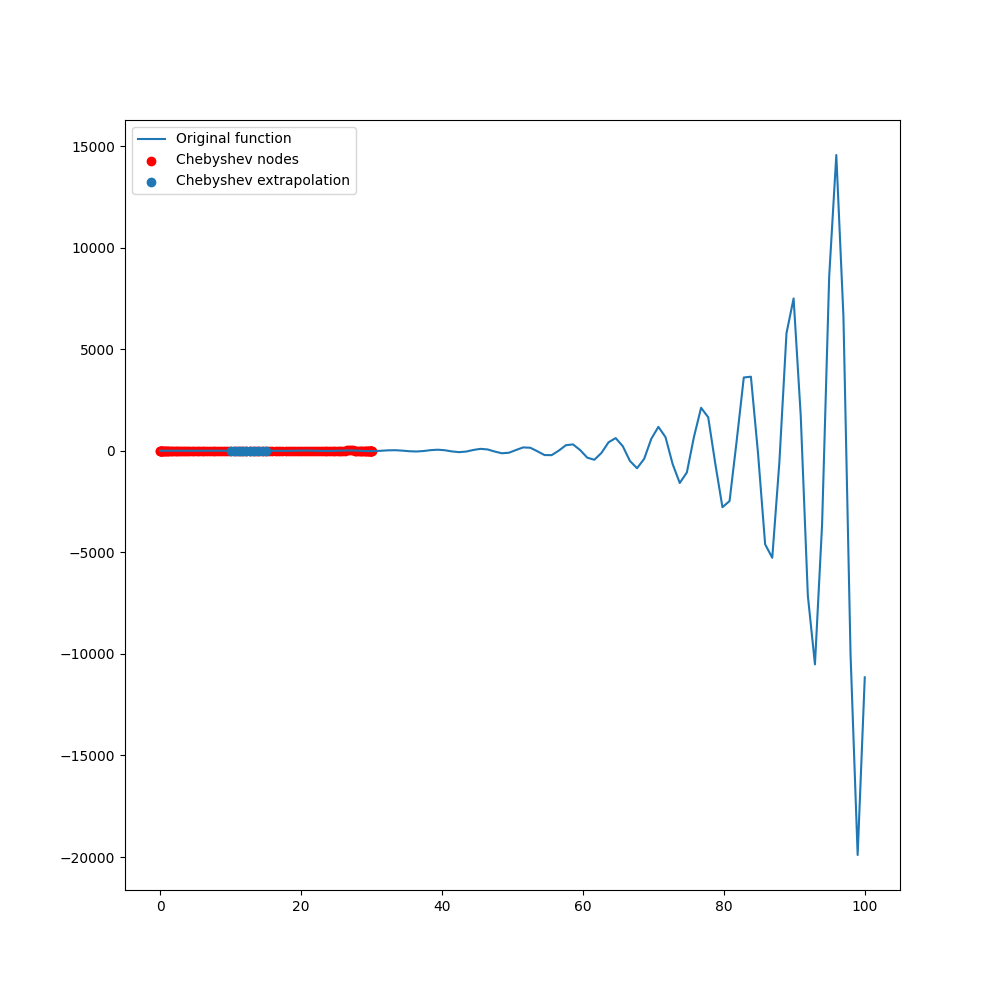

In [4]:
fig, ax = plt.subplots (figsize = (10, 10))

# Plot the function and its approximation
ax.plot(x_ori, f(x_ori), label='Original function')
#ax.plot(x_vals, y_approx, label='Chebyshev approximation')
ax.scatter(x_k_mapped, y_k, color='red', label='Chebyshev nodes')

# Plot the extrapolation
ax.scatter(x_extrap, y_extrap, label='Chebyshev extrapolation')
ax.legend()
plt.show()

### Chebyshev dengan Titik titik yang diketahui

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import Chebyshev
import random

In [6]:
# Data titik-titik yang diketahui

x_known = np.array([0, 5, 10, 15, 20, 25, 30])
y_known = np.array(range (len (x_known)), float)

for i in range (len (x_known)):
    y_known[i] = random.uniform (-2.0, 2.0)

In [7]:
# Interval dari titik-titik yang diketahui
a, b = x_known[0], x_known[-1]

# Menentukan Node Chebyshev
n = len(x_known) - 1

x_k = np.cos((2 * np.arange(n + 1) + 1) * np.pi / (2 * (n + 1)))

# Memetakan Node Chebyshev ke interval yang diketahui
x_k_mapped = 0.5 * (a + b) + 0.5 * (b - a) * x_k

# Menyesuaikan polinomial Chebyshev dengan titik-titik yang diketahui
chebyshev_poly = Chebyshev.fit (x_known, y_known, n)

In [8]:
# Mengevaluasi polinomial pada interval yang diketahui
x_vals = np.linspace (a, b, 100)
y_approx = chebyshev_poly (x_vals)

# Melakukan ekstrapolasi di luar interval yang diketahui
x_extrap = np.linspace(b, b + 10, 10)
y_extrap = chebyshev_poly(x_extrap)

In [9]:
print (f"\t=== Data baru ===\n")
for i in range (len (x_extrap)):
    print (f"\tx[{i}] = {x_extrap[i]} | y[{i}] = {y_extrap[i]}\n")

	=== Data baru ===

	x[0] = 30.0 | y[0] = 0.5634666008527587

	x[1] = 31.11111111111111 | y[1] = 3.155351105711861

	x[2] = 32.22222222222222 | y[2] = 7.661504345636175

	x[3] = 33.333333333333336 | y[3] = 14.93516227035649

	x[4] = 34.44444444444444 | y[4] = 26.059369551259405

	x[5] = 35.55555555555556 | y[5] = 42.38152596573652

	x[6] = 36.666666666666664 | y[6] = 65.5501802003309

	x[7] = 37.77777777777778 | y[7] = 97.55407107268167

	x[8] = 38.888888888888886 | y[8] = 140.76341617226515

	x[9] = 40.0 | y[9] = 197.97344791993604



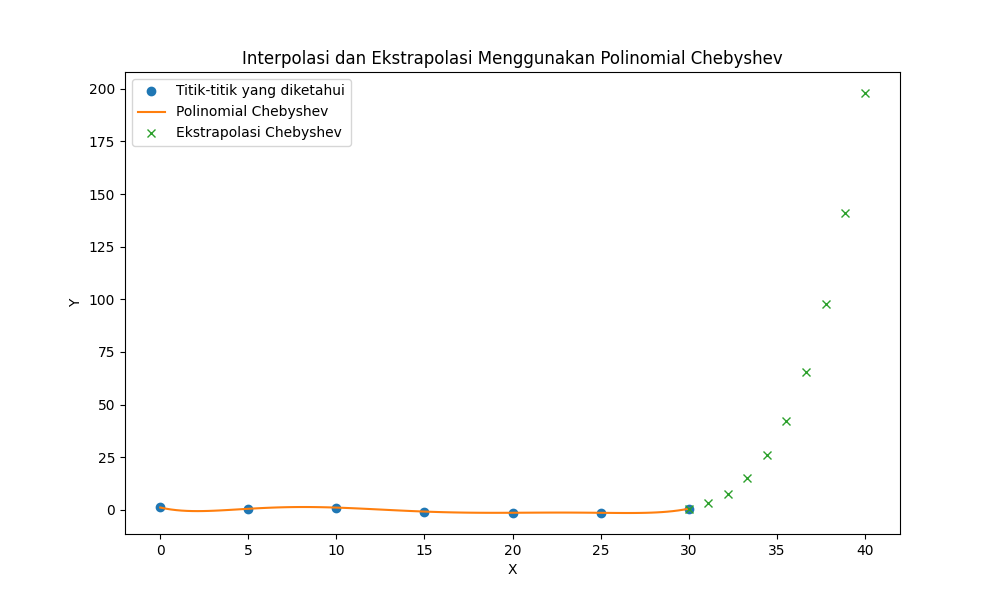

In [10]:
# Plot hasil
fig, ax1 = plt.subplots (figsize=(10, 6))
ax1.plot (x_known, y_known, 'o', label='Titik-titik yang diketahui')
ax1.plot (x_vals, y_approx, '-', label='Polinomial Chebyshev')
ax1.plot (x_extrap, y_extrap, 'x', label='Ekstrapolasi Chebyshev')
ax1.legend ()
ax1.set_xlabel ('X')
ax1.set_ylabel ('Y')
ax1.set_title ('Interpolasi dan Ekstrapolasi Menggunakan Polinomial Chebyshev')
plt.show ()